In [27]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import binom
from matplotlib import pyplot as plt 
from matplotlib_venn import venn2

In [2]:
df = pd.read_csv('student_exam_dataset.csv')

## Types of Events

#### 1. Empirical Probability (Pass hone ki probability)

In [4]:
total_students = len(df)
passed_students = len(df[df['final_exam_pass'] == 'Pass'])
empirical_p = passed_students / total_students

print(f"Empirical Probability (Passing): {empirical_p}")

Empirical Probability (Passing): 0.675


#### 2. Theoretical Probability

In [5]:
theoretical_p = 1 / 2

print(f"Theoretical Probability (Group Discussion): {theoretical_p}")

Theoretical Probability (Group Discussion): 0.5


## Calculate Probability of Passing

In [9]:
total_students = len(df)
print("Total Students:", total_students)

pass_students = len(df[df["final_exam_pass"] == "Pass"])
print("Students Passed:", pass_students)

p = pass_students / total_students
print("Probability of Passing (p):", round(p, 4))

Total Students: 200
Students Passed: 135
Probability of Passing (p): 0.675


## Define Random Variable X

In [12]:
n = 3

x_values = np.arange(0, n+1)

x_values

array([0, 1, 2, 3])

## Construct Probability Distribution Table

In [15]:
probabilities = binom.pmf(x_values, n, p)

dist_table = pd.DataFrame({
    'X (Students Passed)': x_values,
    'Probability P(X)': np.round(probabilities, 4)
})
dist_table

,X (Students Passed),Probability P(X)
0,0,0.0343
1,1,0.2139
2,2,0.4442
3,3,0.3075


In [16]:
# Sum of probabilities 

print("Sum of probabilities:", round(probabilities.sum()))

Sum of probabilities: 1


#### Mean and Variance of this random variable

In [17]:
mean = n * p
variance = n * p * (1 - p)

print("Mean of X:", round(mean, 4))
print("Variance of X:", round(variance, 4))

Mean of X: 2.025
Variance of X: 0.6581


## Venn Diagram in Probability

In [22]:
A = df[df["study_hours"] > 10]

B = df[df["attendance"] > 80]

A_and_B = df[(df["study_hours"] > 10) & (df["attendance"] > 80)]

only_A = len(A) - len(A_and_B)
only_B = len(B) - len(A_and_B)
both = len(A_and_B)

only_A, only_B, both

(89, 15, 74)

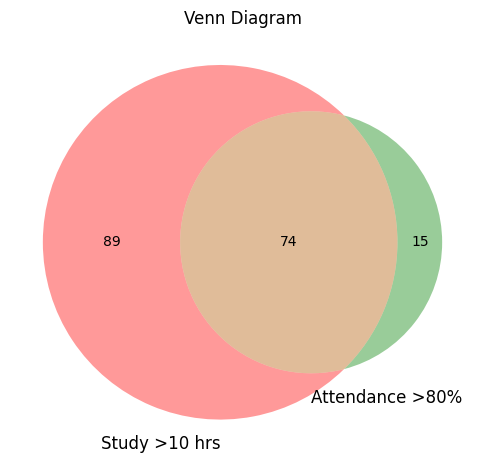

In [28]:
plt.figure(figsize=(6,6))

venn2(
    subsets=(only_A, only_B, both),
    set_labels=("Study >10 hrs", "Attendance >80%")
)

plt.title("Venn Diagram")
plt.show()

## Contingency Table & Probability Calculations

#### Create a Contingency Table

In [29]:
contingency_table = pd.crosstab(df["group_discussion"], df["final_exam_pass"])
contingency_table

final_exam_pass,Fail,Pass
group_discussion,,
No,42,37
Yes,23,98


#### Joint Probability

In [30]:
total_students = contingency_table.values.sum()
total_students

np.int64(200)

In [31]:
joint_yes_pass = contingency_table.loc["Yes","Pass"] / total_students
joint_yes_fail = contingency_table.loc["Yes","Fail"] / total_students
joint_no_pass = contingency_table.loc["No","Pass"] / total_students
joint_no_fail = contingency_table.loc["No","Fail"] / total_students

In [32]:
joint_probability_table = pd.DataFrame({
    "Fail": [joint_no_fail, joint_yes_fail],
    "Pass": [joint_no_pass, joint_yes_pass]
}, index=["No Discussion", "Discussion"])

joint_probability_table

,Fail,Pass
No Discussion,0.210,0.185
Discussion,0.115,0.490


#### Marginal Probability

In [34]:
# P(Discussion)
prob_discussion = contingency_table.loc["Yes"].sum() / total_students
print("P(Discussion) =", prob_discussion)

prob_no_discussion = contingency_table.loc["No"].sum() / total_students
print("P(No Discussion) =", prob_no_discussion)

# P(Pass)
prob_pass = contingency_table["Pass"].sum() / total_students
print("P(Pass) =", prob_pass)

prob_fail = contingency_table["Fail"].sum() / total_students
print("P(Fail) =", prob_fail)

P(Discussion) = 0.605
P(No Discussion) = 0.395
P(Pass) = 0.675
P(Fail) = 0.325


#### Conditional Probability

In [36]:
prob_pass_given_discussion = (
    contingency_table.loc["Yes","Pass"] /
    contingency_table.loc["Yes"].sum()
)
print("P(Pass | Discussion) =", prob_pass_given_discussion)

prob_pass_given_no_discussion = (
    contingency_table.loc["No","Pass"] /
    contingency_table.loc["No"].sum()
)
print("P(Pass | No Discussion) =", prob_pass_given_no_discussion)

P(Pass | Discussion) = 0.8099173553719008
P(Pass | No Discussion) = 0.46835443037974683


## Understanding Relationships

#### Independent & Dependent & Mutually Exclusive Events

In [ ]:
print("P(Yes ∩ Pass) =", joint_yes_pass)
print("P(Yes) × P(Pass) =", prob_discussion * prob_pass)

P(Yes ∩ Pass) = 0.49
P(Yes) × P(Pass) = 0.408375


## Bayes Theorem Application

In [38]:
# P(Discussion)
prob_discussion = contingency_table.loc["Yes"].sum() / total_students

# P(Pass)
prob_pass = contingency_table["Pass"].sum() / total_students

# P(Pass | Discussion)
prob_pass_given_discussion = (
    contingency_table.loc["Yes","Pass"] /
    contingency_table.loc["Yes"].sum()
)

In [39]:
# Bayes Theorem
prob_discussion_given_pass = (
    prob_pass_given_discussion * prob_discussion
) / prob_pass

print("P(Discussion | Pass) =", prob_discussion_given_pass)

P(Discussion | Pass) = 0.7259259259259259
